In [1]:
# Peak vs Off-Peak Charging Analysis

import pandas as pd
import matplotlib.pyplot as plt

# Upload your CSV file in Google Colab first
from google.colab import files
uploaded = files.upload()

# Replace this with your uploaded file name if needed
EV_data = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv(EV_data)

# Preview data
df.head()

Saving charging_ev_and_grid_optimization_dataset.csv to charging_ev_and_grid_optimization_dataset (1).csv


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [2]:
# Check column names
df.columns

Index(['timestamp', 'station_id', 'location_type', 'vehicle_id',
       'vehicle_type', 'arrival_time', 'charging_start_time',
       'charging_end_time', 'waiting_time', 'battery_capacity_kWh',
       'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW',
       'charging_duration', 'queue_length', 'station_load',
       'electricity_price', 'renewable_energy_ratio', 'traffic_density',
       'weather_condition', 'day_of_week', 'time_slot', 'charging_demand',
       'assigned_charger_id', 'charging_priority', 'optimization_reward'],
      dtype='object')

In [3]:
# Convert time columns to datetime
df["arrival_time"] = pd.to_datetime(df["arrival_time"])
df["charging_start_time"] = pd.to_datetime(df["charging_start_time"])
df["charging_end_time"] = pd.to_datetime(df["charging_end_time"])

# Create hour column
df["session_hour"] = df["arrival_time"].dt.hour

# Create peak/off-peak column manually
# Peak hours: 7 AM-10 AM and 5 PM-9 PM
df["peak_offpeak"] = df["session_hour"].apply(
    lambda x: "Peak" if (7 <= x <= 10) or (17 <= x <= 21) else "Off-Peak"
)

df[["arrival_time", "session_hour", "peak_offpeak"]].head()

,arrival_time,session_hour,peak_offpeak
0,2025-01-01 00:00:00,0,Off-Peak
1,2025-01-01 00:15:00,0,Off-Peak
2,2025-01-01 00:30:00,0,Off-Peak
3,2025-01-01 00:45:00,0,Off-Peak
4,2025-01-01 01:00:00,1,Off-Peak


In [4]:
# Peak vs Off-Peak summary

peak_offpeak_summary = df.groupby("peak_offpeak").agg(
    total_sessions=("vehicle_id", "count"),
    total_energy_consumed_kWh=("energy_consumed_kWh", "sum"),
    avg_energy_consumed_kWh=("energy_consumed_kWh", "mean"),
    avg_waiting_time=("waiting_time", "mean"),
    avg_queue_length=("queue_length", "mean"),
    avg_station_load=("station_load", "mean"),
    avg_renewable_energy_ratio=("renewable_energy_ratio", "mean"),
    avg_electricity_price=("electricity_price", "mean"),
    avg_optimization_reward=("optimization_reward", "mean")
).reset_index()

peak_offpeak_summary

,peak_offpeak,total_sessions,total_energy_consumed_kWh,avg_energy_consumed_kWh,avg_waiting_time,avg_queue_length,avg_station_load,avg_renewable_energy_ratio,avg_electricity_price,avg_optimization_reward
0,Off-Peak,5222,203995.35802,39.064603,9.583493,4.647836,34.651387,0.392721,9.971528,-7.056047
1,Peak,3132,122476.83977,39.104994,9.431034,4.497765,84.065917,0.289710,9.940632,-19.801796


In [5]:
# Round results for readability

peak_offpeak_summary_rounded = peak_offpeak_summary.round(2)
peak_offpeak_summary_rounded

,peak_offpeak,total_sessions,total_energy_consumed_kWh,avg_energy_consumed_kWh,avg_waiting_time,avg_queue_length,avg_station_load,avg_renewable_energy_ratio,avg_electricity_price,avg_optimization_reward
0,Off-Peak,5222,203995.36,39.06,9.58,4.65,34.65,0.39,9.97,-7.06
1,Peak,3132,122476.84,39.10,9.43,4.50,84.07,0.29,9.94,-19.80


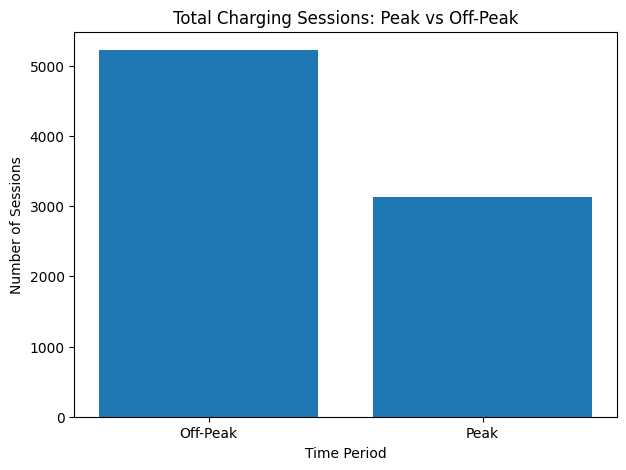

In [6]:
# Bar chart: number of sessions

plt.figure(figsize=(7, 5))
plt.bar(
    peak_offpeak_summary_rounded["peak_offpeak"],
    peak_offpeak_summary_rounded["total_sessions"]
)
plt.title("Total Charging Sessions: Peak vs Off-Peak")
plt.xlabel("Time Period")
plt.ylabel("Number of Sessions")
plt.show()

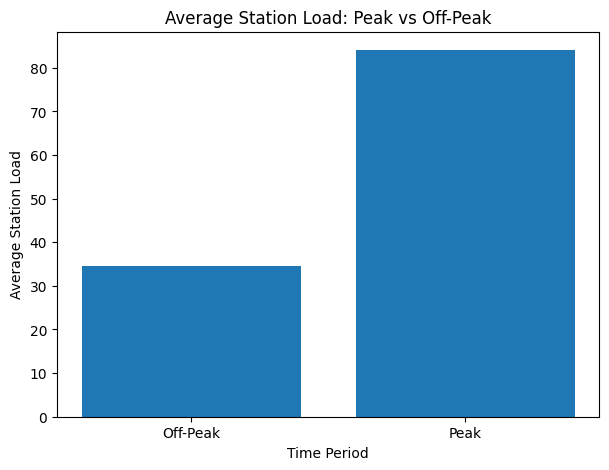

In [8]:
# Bar chart: average station load

plt.figure(figsize=(7, 5))
plt.bar(
    peak_offpeak_summary_rounded["peak_offpeak"],
    peak_offpeak_summary_rounded["avg_station_load"]
)
plt.title("Average Station Load: Peak vs Off-Peak")
plt.xlabel("Time Period")
plt.ylabel("Average Station Load")
plt.show()

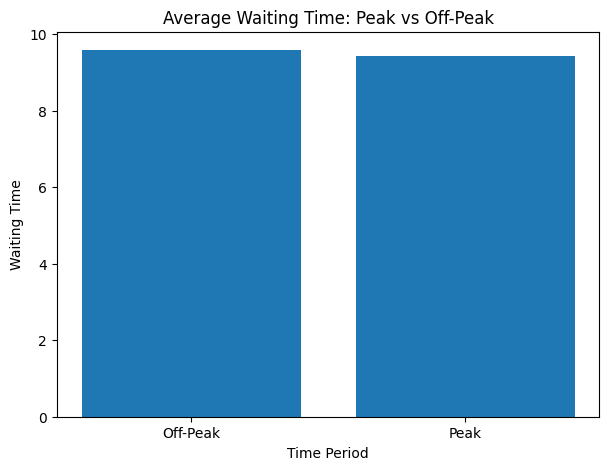

In [9]:
# Bar chart: average waiting time

plt.figure(figsize=(7, 5))
plt.bar(
    peak_offpeak_summary_rounded["peak_offpeak"],
    peak_offpeak_summary_rounded["avg_waiting_time"]
)
plt.title("Average Waiting Time: Peak vs Off-Peak")
plt.xlabel("Time Period")
plt.ylabel("Waiting Time")
plt.show()

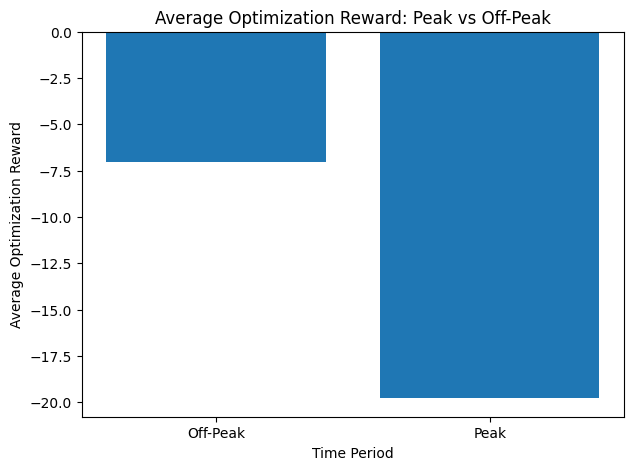

In [10]:
# Bar chart: average optimization reward

plt.figure(figsize=(7, 5))
plt.bar(
    peak_offpeak_summary_rounded["peak_offpeak"],
    peak_offpeak_summary_rounded["avg_optimization_reward"]
)
plt.title("Average Optimization Reward: Peak vs Off-Peak")
plt.xlabel("Time Period")
plt.ylabel("Average Optimization Reward")
plt.show()

In [11]:
# Hourly session trend

hourly_summary = df.groupby("session_hour").agg(
    total_sessions=("vehicle_id", "count"),
    avg_station_load=("station_load", "mean"),
    avg_waiting_time=("waiting_time", "mean"),
    avg_optimization_reward=("optimization_reward", "mean")
).reset_index()

hourly_summary.round(2)

,session_hour,total_sessions,avg_station_load,avg_waiting_time,avg_optimization_reward
0,0,350,24.71,9.05,-8.62
1,1,348,24.25,9.59,-9.20
2,2,348,24.53,9.50,-8.99
3,3,348,25.62,9.54,-9.68
4,4,348,24.50,9.80,-9.30
5,5,348,24.50,9.75,-9.50
6,6,348,24.52,9.97,-9.47
7,7,348,83.90,9.39,-21.16
8,8,348,83.94,9.48,-20.99
9,9,348,83.82,9.24,-21.13


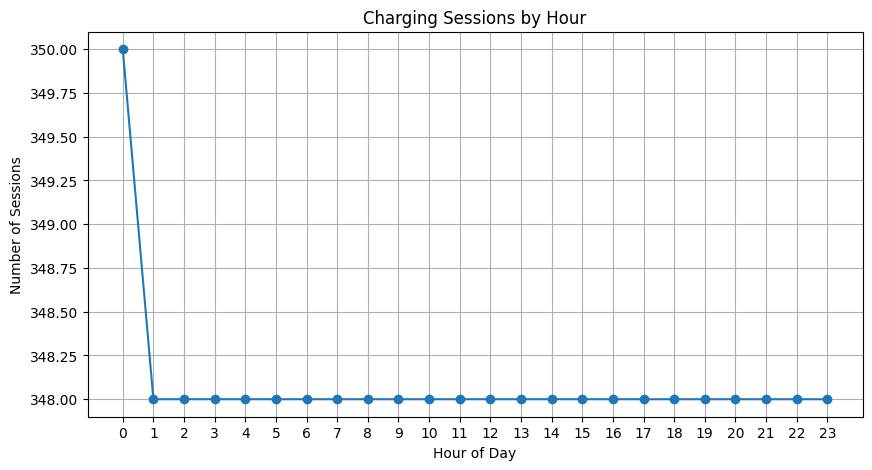

In [12]:
# Line chart: sessions by hour

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_summary["session_hour"],
    hourly_summary["total_sessions"],
    marker="o"
)
plt.title("Charging Sessions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

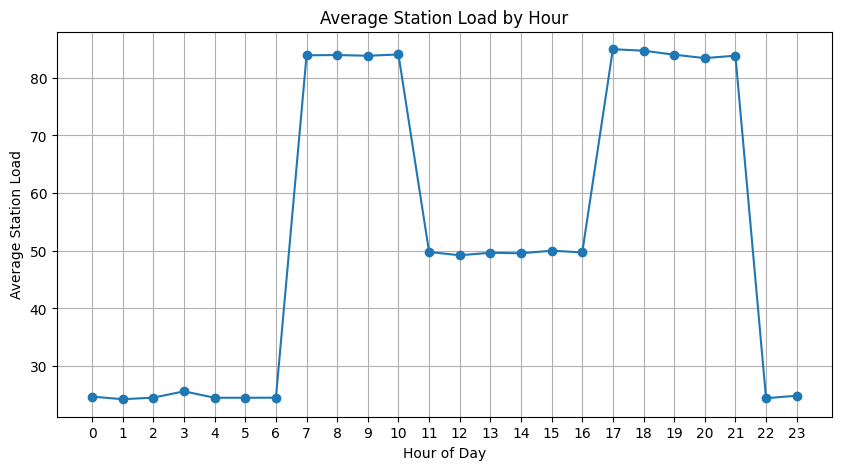

In [13]:
# Line chart: station load by hour

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_summary["session_hour"],
    hourly_summary["avg_station_load"],
    marker="o"
)
plt.title("Average Station Load by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Station Load")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [15]:
# Export peak vs off-peak result

peak_offpeak_summary_rounded.to_csv(
    "peak_vs_offpeak_analysis.csv",
    index=False
)

files.download("peak_vs_offpeak_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>